In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog
import warnings
from matplotlib.gridspec import GridSpec
import corner
import seaborn as sns
import itertools
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

In [2]:
def extraer_datos_de_carpetas(directorio_raiz):
    datos_recopilados = []
    print(f"\n🔍 Escaneando directorio: {directorio_raiz}...")
    
    for root, dirs, files in os.walk(directorio_raiz):
        resumen_file = None
        readme_file = None
        
        for file in files:
            if file.endswith(" resumen.txt") or file.endswith("_resumen.txt"):
                resumen_file = file
            elif file.startswith("README") and file.endswith(".txt"):
                readme_file = file
                
        if resumen_file and readme_file:
            # Convierte "DMPP-1_b" a "DMPP-1 b"
            nombre_planeta = os.path.basename(root).replace("_", " ")
            ruta_resumen = os.path.join(root, resumen_file)
            ruta_readme = os.path.join(root, readme_file)
            
            try:
                # 1. LEER RESUMEN
                with open(ruta_resumen, 'r', encoding='utf-8') as f:
                    contenido_resumen = f.read()
                
                z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_inest_match = re.search(r'Total inestables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_m1_match = re.search(r'Total colisi[oó]n m1:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_m2_match = re.search(r'Total colisi[oó]n m2:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                
                z_est = int(z_est_match.group(1)) if z_est_match else 0
                z_inest = int(z_inest_match.group(1)) if z_inest_match else 0
                z_m1 = int(z_m1_match.group(1)) if z_m1_match else 0
                z_m2 = int(z_m2_match.group(1)) if z_m2_match else 0
                
                # Soportar comas y puntos en los decimales [0-9.,eE+-]
                a_est_match = re.search(r'[AÁaá]rea estable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                a_inest_match = re.search(r'[AÁaá]rea inestable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                a_col_match = re.search(r'[AÁaá]rea.*colisi[oó]n.*m2:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                
                a_est = float(a_est_match.group(1).replace(',', '.')) if a_est_match else 0.0
                a_inest = float(a_inest_match.group(1).replace(',', '.')) if a_inest_match else 0.0
                a_col = float(a_col_match.group(1).replace(',', '.')) if a_col_match else 0.0
                
                # 2. LEER README
                with open(ruta_readme, 'r', encoding='utf-8') as f:
                    contenido_readme = f.read()
                    
                dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                
                distancia = float(dist_match.group(1).replace(',', '.')) if dist_match else 0.0
                masa_planeta = float(masa_p_match.group(1).replace(',', '.')) if masa_p_match else 0.0
                masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 1.0
                
                datos_recopilados.append({
                    "Planeta": nombre_planeta,
                    "Distancia_UA": distancia,
                    "Masa_Tierra": masa_planeta,
                    "Masa_Estrella": masa_estel,
                    "Num_Planetas": 0, # Se calculará más abajo dinámicamente
                    "Zonas Estables": z_est,
                    "Zonas Inestables": z_inest,
                    "Zonas Colisión m1": z_m1,
                    "Zonas Colisión m2": z_m2,
                    "Area_Estable_km2": a_est,
                    "Area_Inestable": a_inest,
                    "Area_Colision_m2": a_col
                })
            except Exception as e:
                print(f"❌ Error interno procesando {nombre_planeta}: {e}")
                
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        # Extraer el nombre del sistema (ej: de "DMPP-1 b" saca "DMPP-1")
        df_resultados["Sistema"] = df_resultados["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
        
        # Contar cuántas filas (planetas) hay por sistema y asignarlo a Num_Planetas
        df_resultados["Num_Planetas"] = df_resultados.groupby("Sistema")["Planeta"].transform("count")

        df_resultados = df_resultados.sort_values(by="Planeta").reset_index(drop=True)
        print(f"✅ Lectura completada. Se extrajeron datos válidos de {len(df_resultados)} planetas.")
        
    return df_resultados

def _safe_log10(x):
    """log10 blindado: retorna log10(x + 1) para evitar log(0) = -inf."""
    return np.log10(np.asarray(x, dtype=float) + 1.0)


def _asignar_estilos_sistema(df: pd.DataFrame) -> dict:
    """
    Genera combinaciones únicas de marcador/color para cada sistema estelar.
    Trabaja sobre la columna 'Sistema' (la crea si no existe).
    Devuelve un dict  {nombre_sistema: {'marker': ..., 'color': ...}}.
    """
    if "Sistema" not in df.columns:
        df = df.copy()
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    sistemas_unicos = df["Sistema"].unique()
    marcadores_base = ["o", "s", "^", "D", "v", "p", "*", "h",
                       "H", "X", "d", "P", "<", ">"]
    colores_base = plt.cm.tab20.colors
    combinaciones = itertools.product(marcadores_base, colores_base)

    estilos = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos[sist] = {"marker": marker, "color": color}

    return estilos

def plot_islands_zonas_estables2(df: pd.DataFrame, base_dir: str):
    metrica = "Area_Estable_km2"
    metrica_label = "Stable Area (km²)" 
    print(f"\nGenerating 2D contour map for: {metrica}...")

    # ── Trabajo sobre copia ──
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    estilos_sistema = _asignar_estilos_sistema(df)

    # Filtrar datos con valores > 0 para el KDE
    df_f = df[df[metrica] > 0].copy()

    if df_f.empty or len(df_f) < 3:
        print(f"Not enough valid data (>0) to generate the {metrica} map.")
        return

    # Paneles
    pnums_unicos = sorted(df_f["Num_Planetas"].unique())
    num_paneles  = len(pnums_unicos) + 1

    fig, axes = plt.subplots(num_paneles, 1, figsize=(18, 10 * num_paneles))
    fig.suptitle(f"2D Contour Maps: Islands of {metrica_label} by Multiplicity",
                 fontsize=24, fontweight="bold", y=0.98)

    if num_paneles == 1:
        axes = [axes]

    # Límites globales 
    dist_pos = df_f["Distancia_UA"][df_f["Distancia_UA"] > 0]
    masa_pos = df_f["Masa_Tierra"][df_f["Masa_Tierra"] > 0]

    if dist_pos.empty or masa_pos.empty:
        print("Not enough positive Distance/Mass data for KDE.")
        return

    x_all = np.log10(dist_pos)
    y_all = np.log10(masa_pos)
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)

    def dibujar_panel(ax, df_subset, titulo, es_general=False):
        if df_subset.empty:
            ax.set_title(titulo + " (No data)",
                         fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return

        # Filtrar filas con Distancia > 0 y Masa > 0
        mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
        df_valid = df_subset[mask_valid].copy()

        if df_valid.empty:
            ax.set_title(titulo + " (No valid data)",
                         fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return

        x = np.log10(df_valid["Distancia_UA"].values)
        y = np.log10(df_valid["Masa_Tierra"].values)

        # Peso KDE blindado con log10(val + 1)
        weights = _safe_log10(df_valid[metrica].values)

        # ── A. MAPA DE CONTORNOS (KDE 2D) ────────────────────────────
        if len(df_valid) > 3 and x.var() > 0 and y.var() > 0:
            try:
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy, weights=weights, bw_method=0.6)

                X, Y = np.mgrid[xlims[0]:xlims[1]:150j,
                                ylims[0]:ylims[1]:150j]
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = np.reshape(kde(positions).T, X.shape)
                Z_flat = Z.flatten()
                
                # Se definen 25 niveles de color
                niveles = np.linspace(np.percentile(Z_flat, 10), np.percentile(Z_flat, 98), 25)

                contour = ax.contourf(X, Y, Z, levels=niveles, cmap="viridis", extend='both')
                cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=30)
                cbar.set_label(f"{metrica_label} Density (log)", fontsize=12)

                # SECCIÓN DE LÍMITES CRÍTICOS
                umbral = niveles[-4]
                indices_alta_densidad = np.where(Z >= umbral)
                x_alta_densidad = X[indices_alta_densidad]
                
                if len(x_alta_densidad) > 0:
                    # Límite Inferior
                    log_dist_minima = np.min(x_alta_densidad)
                    dist_minima_ua = 10**log_dist_minima
                    
                    ax.axvline(x=log_dist_minima, color="black", linestyle="-", linewidth=2.5, 
                               label=f"Lower Critical Limit ({dist_minima_ua:.2f} AU)", zorder=6)

                    ax.text(log_dist_minima - 0.05, 0.92, f"$a_{{min}}=${dist_minima_ua:.2f} AU", 
                            transform=ax.get_xaxis_transform(), color="black", 
                            fontsize=13, fontweight="bold", zorder=7, ha="right",
                            bbox=dict(facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.3"))

                    # Límite Superior
                    log_dist_maxima = np.max(x_alta_densidad)
                    dist_maxima_ua = 10**log_dist_maxima
                    
                    ax.axvline(x=log_dist_maxima, color="black", linestyle="--", linewidth=2.5, 
                               label=f"Upper Critical Limit ({dist_maxima_ua:.2f} AU)", zorder=6)

                    ax.text(log_dist_maxima + 0.05, 0.92, f"$a_{{max}}=${dist_maxima_ua:.2f} AU", 
                            transform=ax.get_xaxis_transform(), color="black", 
                            fontsize=13, fontweight="bold", zorder=7, ha="left",
                            bbox=dict(facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.3"))

            except np.linalg.LinAlgError:
                pass

        # ── B. PUNTOS DE DISPERSIÓN ──────────────────────────────────
        for sist in df_valid["Sistema"].unique():
            df_sist = df_valid[df_valid["Sistema"] == sist]
            props = estilos_sistema.get(
                sist, {"marker": "o", "color": "white"})
            label = sist if not es_general else None
            ax.scatter(np.log10(df_sist["Distancia_UA"]),
                       np.log10(df_sist["Masa_Tierra"]),
                       marker=props["marker"], color=props["color"],
                       s=90, edgecolor="white", linewidth=1.0,
                       label=label, zorder=5)

        # ── C. LÍNEAS FÍSICAS Y REFERENCIAS ─────────────────────────
        ax.axhline(y=np.log10(10), color="orange", linestyle="--",
                   linewidth=2, label="Rocky / Neptunian Limit", zorder=4)
        ax.axhline(y=np.log10(50), color="lime", linestyle="--",
                   linewidth=2, label="Neptunian / Giant Limit", zorder=4)

        ax.scatter(0, 0, marker="*", color="gold", s=350, edgecolor="black", 
                   linewidth=1.2, label=r"Earth (1 AU, 1 $M_\oplus$, $A_{stab}=1.27 \times 10^{13}$ km$^2$)", zorder=10)

        # ── D. ESTÉTICA ──────────────────────────────────────────────
        ax.set_title(titulo, fontsize=18, fontweight="bold", pad=15)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_xlabel("log[Distance] (AU)", fontsize=14)
        ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=14)
        ax.grid(True, which="both", ls="--", color="white", alpha=0.3, zorder=0)

        # ── E. LEYENDAS ─────────────────────────────────────────────
        if not es_general:
            ax.legend(loc="upper left", bbox_to_anchor=(1.22, 1),
                      frameon=True, shadow=True,
                      title="Systems and References", ncol=2, fontsize=10)
        else:
            handles, labels = ax.get_legend_handles_labels()
            criterios = ["Limit", "Earth"]
            line_handles = [h for h, l in zip(handles, labels) if any(c in l for c in criterios)]
            line_labels  = [l for l in labels if any(c in l for c in criterios)]
            if line_handles:
                ax.legend(line_handles, line_labels, loc="upper left",
                          bbox_to_anchor=(1.22, 1),
                          frameon=True, shadow=True, fontsize=10)

    # ── EJECUCIÓN DE LOS PANELES ─────────────────────────────────────────
    dibujar_panel(axes[0], df_f,
                  f"Global View: All systems",
                  es_general=True)

    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f["Num_Planetas"] == pnum].copy()
        dibujar_panel(axes[i + 1], df_sub,
                      f"Systems with {pnum} planets",
                      es_general=False)

    plt.tight_layout(rect=[0, 0.03, 0.82, 0.98])

    nombre_base = metrica.replace(" ", "_")
    ruta_png = os.path.join(base_dir, f"Map_2D_Islands_{nombre_base}_Vertical.png")
    ruta_pdf = os.path.join(base_dir, f"Map_2D_Islands_{nombre_base}_Vertical.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)
def plot_islands_of_stability(df, base_dir):
    """
    Genera un mapa de contornos de densidad 2D (KDE) vertical.
    Panel superior: Visión global.
    Paneles inferiores: Filtrados por multiplicidad, con marcadores por sistema.
    """
    # 1. Filtrar datos con áreas válidas (>0) para evitar log(0)
    df_f = df[df['Area_Estable_km2'] > 0].copy()
    if df_f.empty:
        print("No hay datos válidos con Área > 0 para graficar.")
        return

    # 2. Extraer el nombre del Sistema (Ej: "DMPP-1 b" -> "DMPP-1")
    df_f['Sistema'] = df_f['Planeta'].apply(lambda x: str(x).rsplit(' ', 1)[0])
    sistemas_unicos = df_f['Sistema'].unique()
    
    # 3. Generar combinaciones únicas de Marcadores y Colores para cada Sistema
    marcadores_base = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'H', 'X', 'd', 'P', '<', '>']
    colores_base = plt.cm.tab20.colors # 20 colores distintos
    combinaciones = itertools.product(marcadores_base, colores_base)
    
    estilos_sistema = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos_sistema[sist] = {'marker': marker, 'color': color}

    # 4. Determinar número de paneles
    pnums_unicos = sorted(df_f['Num_Planetas'].unique())
    num_paneles = len(pnums_unicos) + 1
    
    # --- CAMBIO 1: Figura mucho más ancha e intervalos más altos ---
    # Tamaño aumentado a 18 de ancho y 10 de alto por cada panel
    fig, axes = plt.subplots(num_paneles, 1, figsize=(18, 10 * num_paneles))
    fig.suptitle("Mapas de Contorno 2D: Islas de Estabilidad por Multiplicidad", 
                 fontsize=24, fontweight='bold', y=0.98)
    
    if num_paneles == 1:
        axes = [axes]

    # --- CAMBIO 2: Márgenes más amplios (Padding de 0.4) ---
    x_all = np.log10(df_f['Distancia_UA'])
    y_all = np.log10(df_f['Masa_Tierra'])
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)

    # ==========================================
    # FUNCIÓN INTERNA PARA DIBUJAR CADA PANEL
    # ==========================================
    def dibujar_panel(ax, df_subset, titulo, es_general=False):
        x = np.log10(df_subset['Distancia_UA'].values)
        y = np.log10(df_subset['Masa_Tierra'].values)
        weights = np.log10(df_subset['Area_Estable_km2'].values)
        
        # --- A. MAPA DE CONTORNOS (KDE 2D) ---
        # Se requieren al menos 3 puntos y varianza para evitar matrices singulares
        if len(df_subset) > 3 and x.var() > 0 and y.var() > 0:
            try:
                xy = np.vstack([x, y])
                
                # --- CAMBIO 3: Factor de Suavizado (Bandwidth = 0.45) ---
                kde = gaussian_kde(xy, weights=weights, bw_method=0.45)
                
                # Crear la malla base (Resolución aumentada a 150j)
                X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = np.reshape(kde(positions).T, X.shape)
                
                # Graficar contornos (Niveles aumentados a 25)
                contour = ax.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.85)
                
                # Agregar barra de color ajustada
                cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=30)
                cbar.set_label('Densidad del Área (KDE)', fontsize=12)
            except np.linalg.LinAlgError:
                pass # Si los datos son colineales, omite el fondo pero dibuja los puntos

        # --- B. PUNTOS DE DISPERSIÓN (SCATTER POR SISTEMA) ---
        sistemas_en_panel = df_subset['Sistema'].unique()
        for sist in sistemas_en_panel:
            df_sist = df_subset[df_subset['Sistema'] == sist]
            props = estilos_sistema[sist]
            
            # Etiqueta solo si estamos en un sub-panel (el panel 0 tendría demasiadas)
            label = sist if not es_general else None
            
            # Puntos más grandes (s=90)
            ax.scatter(np.log10(df_sist['Distancia_UA']), 
                       np.log10(df_sist['Masa_Tierra']), 
                       marker=props['marker'], color=props['color'], 
                       s=90, edgecolor='white', linewidth=1.0, label=label, zorder=5)

        # --- C. LÍNEAS DE LÍMITES FÍSICOS ---
        ax.axhline(y=np.log10(10), color='cyan', linestyle='--', linewidth=2, 
                   label='Límite Rocoso / Neptuniano', zorder=4)
        ax.axhline(y=np.log10(50), color='magenta', linestyle='--', linewidth=2, 
                   label='Límite Neptuniano / Gigante', zorder=4)

        # --- D. ESTÉTICA DEL EJE ---
        ax.set_title(titulo, fontsize=18, fontweight='bold', pad=15)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_xlabel("log[Distancia] (UA)", fontsize=14)
        ax.set_ylabel(r"log[Masa Planetaria] ($M_\oplus$)", fontsize=14)
        ax.grid(True, which="both", ls="--", color='white', alpha=0.3, zorder=0)

        # --- E. LEYENDAS ---
        # Posicionamos la leyenda lejos (bbox a 1.22) para que no choque con la Colorbar
        if not es_general:
            ax.legend(loc='upper left', bbox_to_anchor=(1.22, 1), frameon=True, 
                      shadow=True, title="Sistemas", ncol=2, fontsize=10)
        else:
            # En el panel general, solo mostramos la leyenda de las líneas divisorias
            handles, labels = ax.get_legend_handles_labels()
            line_handles = [h for h, l in zip(handles, labels) if 'Límite' in l]
            line_labels = [l for l in labels if 'Límite' in l]
            if line_handles:
                ax.legend(line_handles, line_labels, loc='upper left', 
                          bbox_to_anchor=(1.22, 1), frameon=True, shadow=True, fontsize=10)

    # ==========================================
    # EJECUCIÓN DE LOS PANELES
    # ==========================================
    
    # PANEL 0: Todos los sistemas (Visión Global)
    dibujar_panel(axes[0], df_f, "Visión Global: Todos los sistemas", es_general=True)

    # PANELES 1 al N: Filtrados por cantidad de planetas
    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f['Num_Planetas'] == pnum]
        dibujar_panel(axes[i+1], df_sub, f"Sistemas con {pnum} planetas", es_general=False)

    # Ajuste del lienzo para dar espacio a colorbars y leyendas derechas
    plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
    
    # Guardar gráficos
    ruta_png = os.path.join(base_dir, "Mapa_Islas_Estabilidad_Vertical_Expandido.png")
    ruta_pdf = os.path.join(base_dir, "Mapa_Islas_Estabilidad_Vertical_Expandido.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close(fig)

In [3]:
def plot_histogramas_y_limites_1d(df: pd.DataFrame, base_dir: str):
    """
    Genera histogramas y modelos KDE 1D para la Distancia y la Masa,
    ponderados por el Área Estable, para extraer y visualizar los límites físicos.
    """
    print("\nGenerando análisis 1D (Histogramas + KDE) para límites de Distancia y Masa...")
    
    # Filtrar datos válidos (> 0)
    mask_valid = (df["Distancia_UA"] > 0) & (df["Masa_Tierra"] > 0) & (df["Area_Estable_km2"] > 0)
    df_v = df[mask_valid].copy()
    
    if len(df_v) < 3:
        print("No hay suficientes datos válidos para generar histogramas y KDE 1D.")
        return

    # Extraer variables en escala logarítmica y aplicar peso
    log_dist = np.log10(df_v["Distancia_UA"].values)
    log_masa = np.log10(df_v["Masa_Tierra"].values)
    pesos = _safe_log10(df_v["Area_Estable_km2"].values)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Análisis 1D de Límites de Estabilidad (Histograma + KDE)", fontsize=18, fontweight="bold", y=0.98)

    def analizar_y_graficar_1d(ax, datos, pesos, xlabel, titulo, unidad_original):
        # 1. Histograma base
        ax.hist(datos, bins=15, weights=pesos, density=True, color='skyblue', 
                edgecolor='white', alpha=0.7, label='Datos (Histograma)')

        # 2. Modelo KDE 1D
        kde = gaussian_kde(datos, weights=pesos, bw_method=0.45)
        x_grid = np.linspace(datos.min() - 0.5, datos.max() + 0.5, 500)
        y_kde = kde(x_grid)
        
        ax.plot(x_grid, y_kde, color='darkblue', linewidth=2.5, label='Modelo KDE')

        # 3. Cálculo de Límites (Umbral: Definimos el límite donde la densidad cae al 10% del pico)
        densidad_maxima = y_kde.max()
        umbral = densidad_maxima * 0.10
        indices_superan_umbral = np.where(y_kde >= umbral)[0]

        if len(indices_superan_umbral) > 0:
            idx_min = indices_superan_umbral[0]
            idx_max = indices_superan_umbral[-1]
            
            x_min, x_max = x_grid[idx_min], x_grid[idx_max]
            val_min_orig, val_max_orig = 10**x_min, 10**x_max

            # Sombreado de la zona de alta probabilidad
            ax.fill_between(x_grid, 0, y_kde, where=(y_kde >= umbral), color='orange', alpha=0.2, 
                            label='Zona Principal (>10% dens. máx)')
            
            # Líneas de límite extraídas matemáticamente del KDE
            ax.axvline(x_min, color='red', linestyle='--', linewidth=2, 
                       label=f'Lím. Inferior: {val_min_orig:.2f} {unidad_original}')
            ax.axvline(x_max, color='green', linestyle='--', linewidth=2, 
                       label=f'Lím. Superior: {val_max_orig:.2f} {unidad_original}')

        ax.set_title(titulo, fontsize=14, fontweight="bold", pad=15)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("Densidad Ponderada", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right', fontsize=10)

    # Generar panel izquierdo: Distancia
    analizar_y_graficar_1d(axes[0], log_dist, pesos, 
                           "log[Distancia] (UA)", 
                           "Distribución de Distancia", "UA")

    # Generar panel derecho: Masa
    analizar_y_graficar_1d(axes[1], log_masa, pesos, 
                           r"log[Masa Planetaria] ($M_\oplus$)", 
                           "Distribución de Masa", r"$M_\oplus$")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Guardar resultados
    ruta_png = os.path.join(base_dir, "Analisis_Limites_1D_Hist_KDE.png")
    ruta_pdf = os.path.join(base_dir, "Analisis_Limites_1D_Hist_KDE.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    
    plt.show()
    plt.close(fig)

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M...
✅ Lectura completada. Se extrajeron datos válidos de 170 planetas.

 Diagnóstico: En esta carpeta hay sistemas con las siguientes cantidades de planetas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]
Se graficarán 163 planetas que pertenecen a sistemas de 3 o más planetas.

Generando análisis 1D (Histogramas + KDE) para límites de Distancia y Masa...


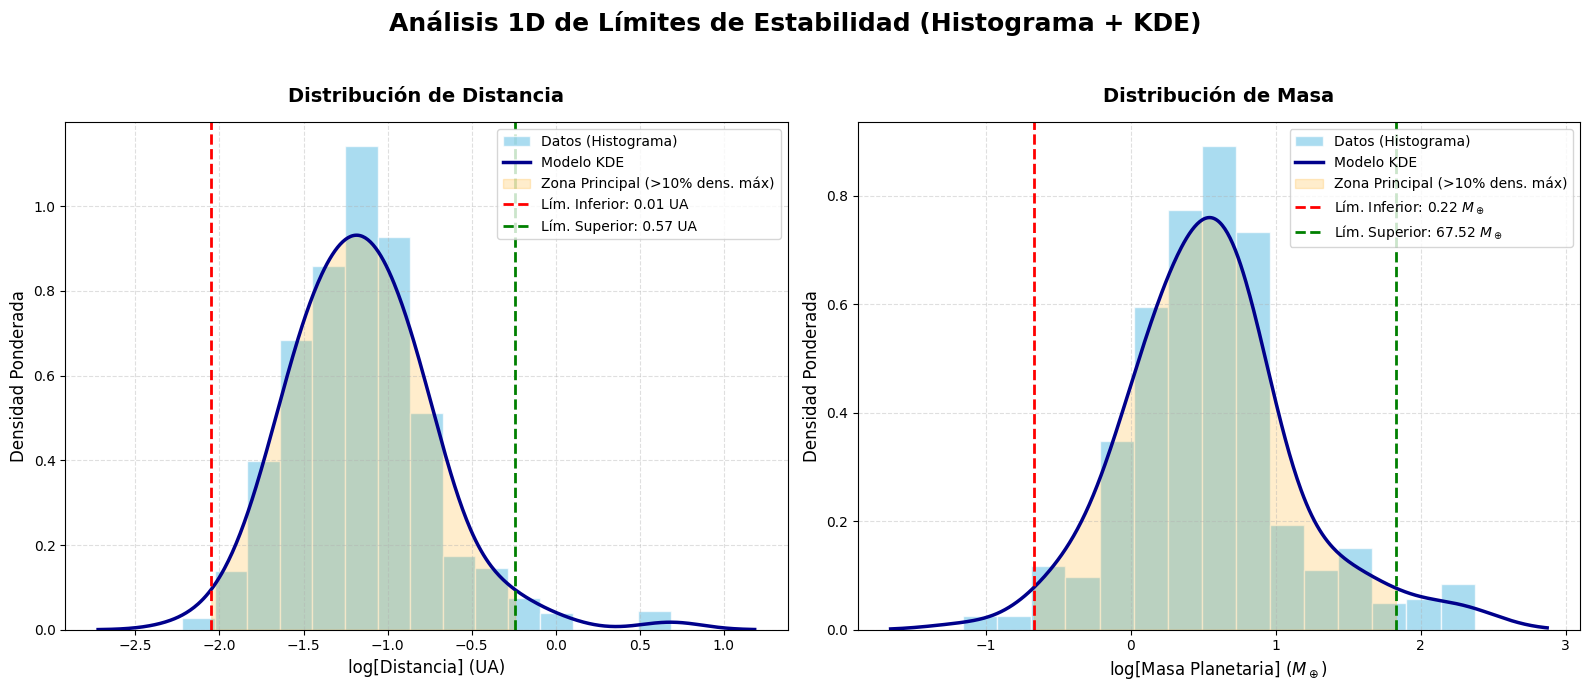


Gráficos generados con éxito.


In [4]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # --- DIAGNÓSTICO ---
            cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
            print(f"\n Diagnóstico: En esta carpeta hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
            
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                print(f"Se graficarán {len(df_filtrado)} planetas que pertenecen a sistemas de 3 o más planetas.")
                
                # Función correcta
                plot_histogramas_y_limites_1d(df_filtrado, DIRECTORIO_RAIZ)
                print("\nGráficos generados con éxito.")
                
            else:
                print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
                
        else:
            print("\nNo se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n Operación cancelada por el usuario.")